In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
def extract_data(filedir):
    files = os.listdir(filedir)
    df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
    df_list = [df.drop(0) for df in df_list]
    df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
    data = pd.concat(df_list, ignore_index=True)    
    return data


dir1 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_83"
dir2 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_e8"


data1 = extract_data(dir1)
data2 = extract_data(dir2)

print(data1.shape)
print(data2.shape)

C:\Users\Shubai\AppData\Local\Temp\ipykernel_16036\1564843815.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_16036\1564843815.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_16036\1564843815.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shub

(359064, 15)
(460404, 15)


In [5]:
def time_transform(arr):

    arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
    secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
    return secs

time_onchip1 = time_transform([x.split(" ", 2)[2] for x in data1[2]])
time_onchip2 = time_transform([x.split(" ", 2)[2] for x in data2[2]])


time_sys1 = time_transform(data1[0])
time_sys2 = time_transform(data2[0])


In [6]:
#测试掉帧
t1 = time_onchip1
t2 = time_onchip2


def frameloss_test(t):
    fl_count = 0
    lostframes = 0 
    for i in range(1, len(t)):
        if float(t[i]) - float(t[i-1]) >= 0.02:
            fl_count += 1
            lostframes += int((t[i] - t[i-1]) / 0.01) - 1
            #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
    print(f"frame loss count: {fl_count}")
    print(f"total lost frames: {lostframes}")

frameloss_test(t1)
frameloss_test(t2)


frame loss count: 6
total lost frames: 28
frame loss count: 335
total lost frames: 2699


In [7]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

In [8]:
t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1.values)
t_new2, sig2, sig_ori2, fs2, drift2, t_est2 = align_imu(data2.values)

In [9]:
t_new1 = t_new1-t_new1[0]
t_new2 = t_new2-t_new2[0]

ta = t_new1 - 7  
tb = t_new2 - 7  

ta_p = ta[ta >= 0]
ndrop = len(ta) - len(ta_p)
imu_a = sig1[-len(ta_p):]

tb_p = tb[tb >= 0]
ndrop = len(tb) - len(tb_p)
imu_b = sig2[-len(tb_p):]

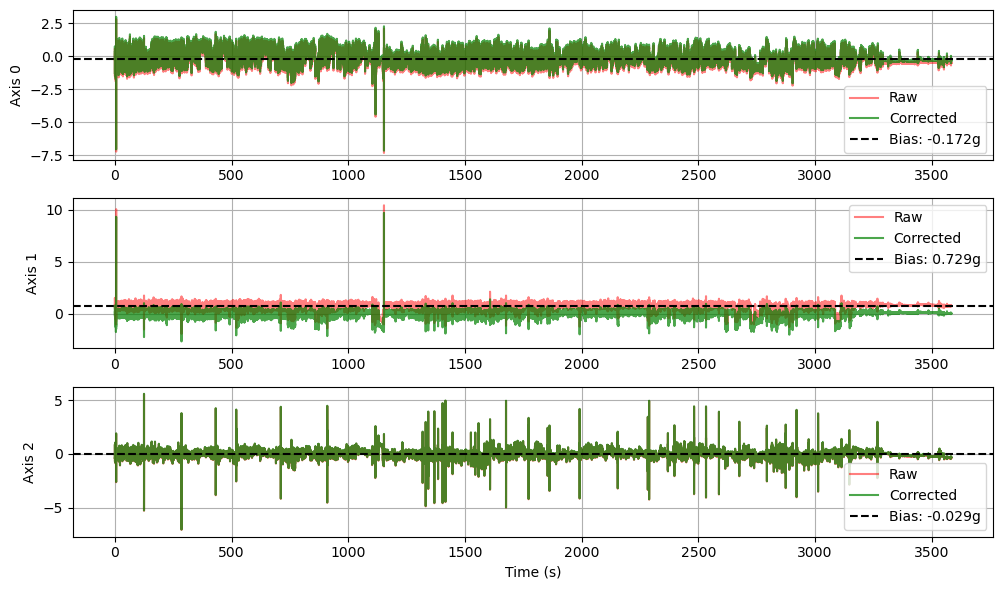

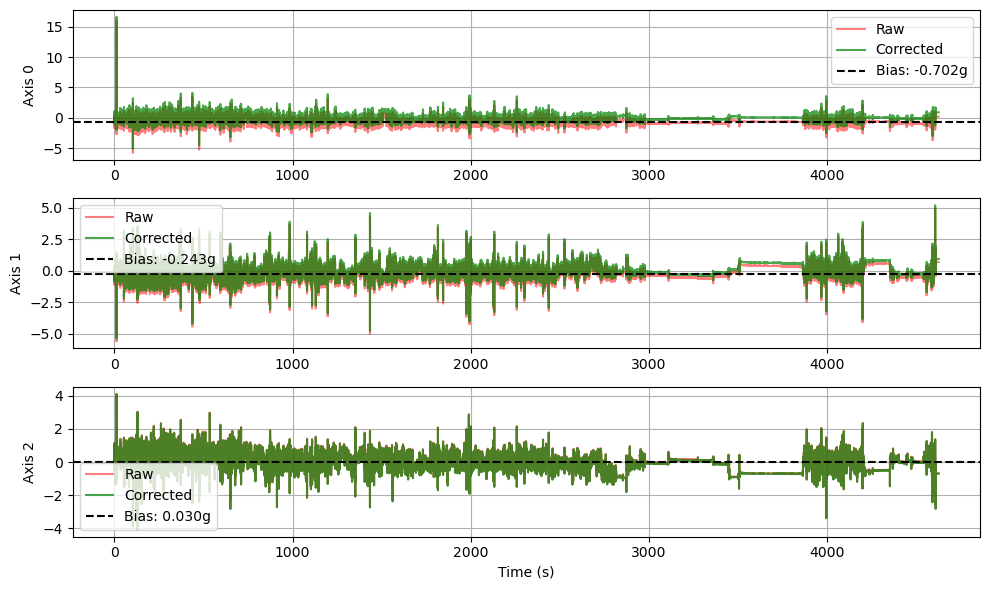

In [10]:
#重力偏移校正（暂时不需要，在DISSeCT方法中，直接跳到下一步构建AG和AnG）
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def correct_imu_simple(data_9col, fs=100, cutoff=0.1):
    """
    最简IMU校正：9列输入 -> 校正后9列输出
    仅校正加速度前3列，陀螺仪后3列保持不变
    """
    acc = data_9col[:, :3].copy()
    
    # 零偏估计：低通滤波
    nyquist = 0.5 * fs
    b, a = butter(2, cutoff/nyquist, btype='low')
    bias = np.array([np.mean(filtfilt(b, a, acc[:, i])) for i in range(3)])
    
    # 校正
    acc_corrected = acc - bias
    
    # 合并输出
    result = data_9col.copy()
    result[:, :3] = acc_corrected
    
    # 可视化
    fig, ax = plt.subplots(3, 1, figsize=(10, 6))
    t = np.arange(len(acc)) / fs
    for i in range(3):
        ax[i].plot(t, acc[:, i], 'r', alpha=0.5, label='Raw')
        ax[i].plot(t, acc_corrected[:, i], 'g', alpha=0.7, label='Corrected')
        ax[i].axhline(bias[i], color='k', linestyle='--', label=f'Bias: {bias[i]:.3f}g')
        ax[i].set_ylabel(f'Axis {i}')
        ax[i].legend()
        ax[i].grid(True)
    ax[2].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig('correction_result.png')
    
    return result, bias


imu_a1, estimated_bias1 = correct_imu_simple(imu_a, fs=100)
imu_b1, estimated_bias2 = correct_imu_simple(imu_b, fs=100)

In [11]:
#IMU数据预处理，从原始数据建立AG、AnG和w，将角度接在后面
import numpy as np

def preprocess_segment(data):
    """
    单段 9 轴 IMU 预处理。
    
    输入
    ----
    data : np.ndarray, shape (n, 9)
        列顺序: [ax, ay, az, wx, wy, wz, roll, pitch, yaw]
        单位: 加速度(g), 角速度(°/s), 角度(°)
        
    输出
    ----
    np.ndarray, shape (n, 12)
        列顺序: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
    """
    a_raw = data[:, 0:3].astype(float)
    w_raw = data[:, 3:6].astype(float)
    r_deg = data[:, 6:9].astype(float)

    # 1. 陀螺仪零偏：整段中位数（角速度理论上均值为0）
    w = w_raw - np.median(w_raw, axis=0)

    # 2. 欧拉角 -> 旋转矩阵 R (head -> Earth, ZYX 内旋: yaw→pitch→roll)
    #    如果传感器角度顺序不同，请修改此矩阵
    r = np.radians(r_deg)
    cr, sr = np.cos(r[:, 0]), np.sin(r[:, 0])   # roll
    cp, sp = np.cos(r[:, 1]), np.sin(r[:, 1])   # pitch
    cy, sy = np.cos(r[:, 2]), np.sin(r[:, 2])   # yaw

    R = np.zeros((len(data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr

    # 3. 头部参考系中的重力分量 aG = R^T · [0, 0, 1]
    aG = np.einsum('nij,j->ni', R.transpose(0, 2, 1), np.array([0., 0., 1.]))

    # 验证：aG 模长必须恒为 1.0。若报错，说明角度顺序/定义与代码不符
    assert np.allclose(np.linalg.norm(aG, axis=1), 1.0, atol=0.05), \
        "aG 模长不恒为 1g，请检查 roll/pitch/yaw 是否为 ZYX 内旋顺序"

    # 4. 加速度零偏：利用 anG 应近似零均值的特性
    #    a_raw = aG + anG_true + bias  =>  a_raw - aG = anG_true + bias
    #    取中位数即可分离出 bias（假设真实运动加速度 anG_true 的中位数为0）
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # 5. 非重力加速度
    anG = a - aG
    list_new = np.concatenate([aG, anG, w, r_deg], axis=1)

    return list_new

imu_preprocessed1 = preprocess_segment(imu_a)
imu_preprocessed2 = preprocess_segment(imu_b)

In [12]:
%matplotlib inline


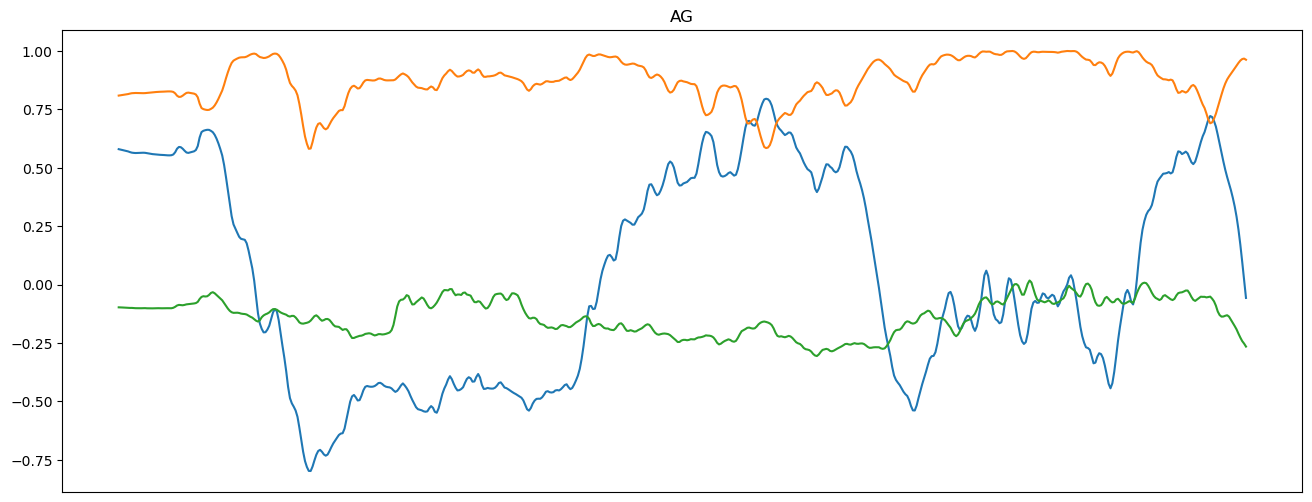

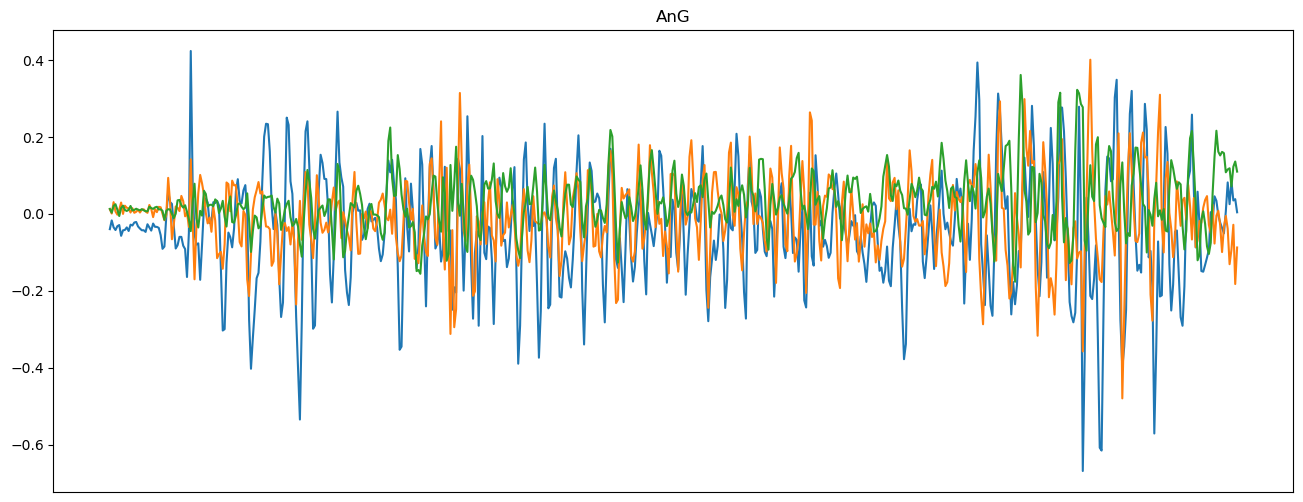

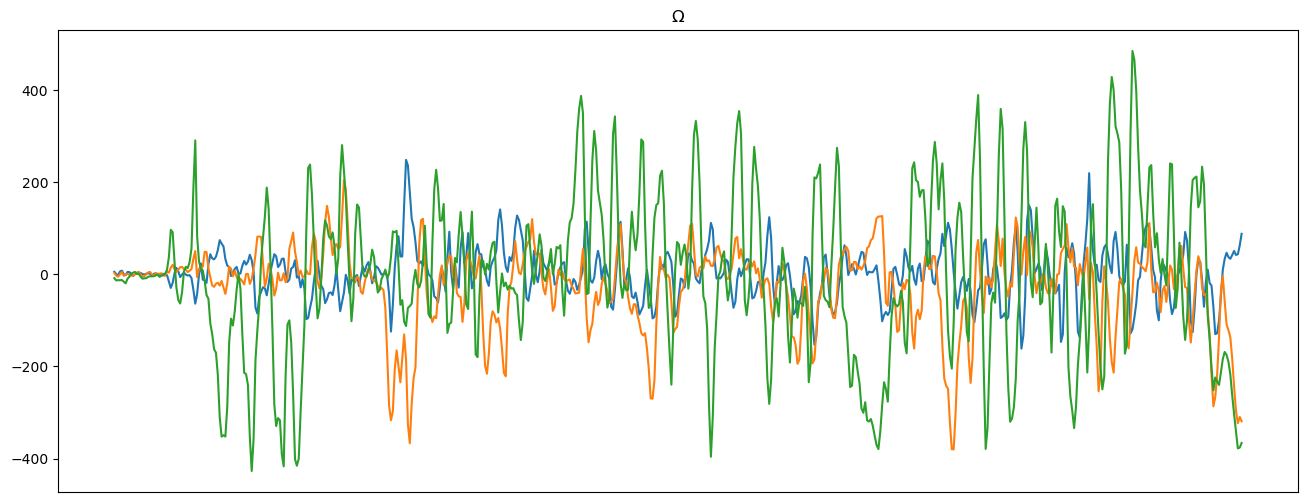

In [15]:
#绘图检查时间和视频对应关系
import matplotlib.pyplot as plt

start = 50000
end = 50600
figsize = (16, 6)

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,0])
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,1])
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,2])
ax.xaxis.set_major_locator(plt.MultipleLocator(200))  # 间隔改为1
plt.title("AG")
plt.show()

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,3])
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,4])
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,5])
ax.xaxis.set_major_locator(plt.MultipleLocator(200))
plt.title("AnG")
plt.show()

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,6])
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,7])
ax.plot(t_new1[start:end], imu_preprocessed1[start:end,8])
ax.xaxis.set_major_locator(plt.MultipleLocator(200))
plt.title("Ω")
plt.show()


In [16]:
#DISSeCT变点检测
import numpy as np
import ruptures as rpt
from tqdm import tqdm

import numpy as np
import ruptures as rpt

def dissect_imu(data, sr=100.0, min_size=10, penalty=14.0):
    """
    单线程分块 PELT。输入 data 应为 1min 左右的片段。
    """
    n_samples = len(data)
    
    # 取 aG + ω
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    
    # z-score
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    # median heuristic
    n_select = min(10000, n_samples)
    idx_sel = np.random.choice(n_samples, n_select, replace=False)
    x_selected = signal_z[idx_sel]
    gram = x_selected @ x_selected.T
    median_gram = np.median(gram)
    gamma = 1.0 / median_gram if median_gram != 0 else 1.0
    
    # 1min 分块（如果输入就是 1min，这里 block_size ≈ n_samples，实际只跑 1 块）
    block_size = int(60.0 * sr)
    all_bkps = []
    
    for start in range(0, n_samples, block_size):
        end = min(start + block_size, n_samples)
        if end - start < 2 * min_size:
            continue
            
        block = signal_z[start:end]
        algo = rpt.Pelt(model="rbf", params={"gamma": gamma}, min_size=min_size, jump=1)
        algo.fit(block)
        bkps = algo.predict(pen=penalty)
        
        # 转全局索引，去掉块内最后一个边界
        all_bkps.extend([b + start for b in bkps[:-1]])
    
    # 最终边界
    all_bkps = sorted(set(all_bkps))
    all_bkps.append(n_samples)
    
    # 切割
    segments = []
    start = 0
    for end in all_bkps:
        if end - start >= min_size:
            segments.append(data[start:end, :])
        start = end
    
    return segments

In [13]:
#将数据切割为30s的片段

def segmentation(t, imu):
    data_seg = []
    t_seg = []
    seg_len = 60
    edges = np.arange(t[0] // seg_len * seg_len, t[-1] + seg_len, seg_len)
    ix = np.searchsorted(t, edges)

    for s, e in zip(ix, ix[1:]):
        if e <= s: continue
        ti, imui = t[s:e], imu[s:e]
        # 处理该段：满10min或不足10min的尾段均保留
        data_seg.append(imui)
        t_seg.append(ti)
    return data_seg, t_seg


seg_data1, seg_t1 = segmentation(ta_p, imu_preprocessed1)
seg_data2, seg_t2 = segmentation(tb_p, imu_preprocessed2)


In [14]:
print(seg_data1[6])

[[-5.10227729e-01  6.46086987e-01 -5.67661228e-01 ...  1.31303000e+02
   3.06789999e+01  8.32930002e+01]
 [-5.16234404e-01  6.45986401e-01 -5.62319847e-01 ...  1.31039000e+02
   3.10800000e+01  8.25460002e+01]
 [-5.14259923e-01  6.46930881e-01 -5.63042775e-01 ...  1.31034000e+02
   3.09480000e+01  8.20180000e+01]
 ...
 [-4.38449571e-01  8.93941559e-01  9.29002821e-02 ...  8.40669996e+01
   2.60049995e+01  1.41519999e+02]
 [-4.67590426e-01  8.80381008e-01  7.92999000e-02 ...  8.48529999e+01
   2.78779992e+01  1.42795000e+02]
 [-5.12537490e-01  8.55463644e-01  7.40761393e-02 ...  8.50509999e+01
   3.08329990e+01  1.43652000e+02]]


In [17]:
import numpy as np
import ruptures as rpt

def compute_global_gamma(seg_list):
    """
    从多个片段（如前三段）中计算全局稳定的 gamma。
    seg_list: list of np.ndarray, each (n, 12)
    """
    # 合并所有片段的 aG + ω
    all_signal = []
    for seg in seg_list:
        signal_cpd = np.concatenate([seg[:, 0:3], seg[:, 6:9]], axis=1)
        all_signal.append(signal_cpd)
    
    full_signal = np.vstack(all_signal)
    
    # z-score
    mu = np.mean(full_signal, axis=0)
    sigma = np.std(full_signal, axis=0) + 1e-12
    signal_z = (full_signal - mu) / sigma
    
    # 基于总方差的稳定 gamma
    total_var = np.sum(np.var(signal_z, axis=0))
    gamma = 1.0 / total_var if total_var > 0 else 1.0
    
    return gamma

def search_penalty_for_target_duration(data, gamma, sr=100.0, min_size=10, target_ms=377.0):
    """
    搜索 penalty，使得中位段长接近目标时长（毫秒）。
    返回最优 penalty 和对应的中位段长（毫秒）。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return 0.1, n_samples / sr * 1000.0
    
    # 准备 CPD 输入信号
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    # 目标段长（样本数）
    target_len = target_ms / 1000.0 * sr
    
    # 在 log 空间搜索 penalty
    penalties = np.logspace(-1, 2, 30)  # 0.1 ~ 100
    best_pen = penalties[0]
    best_err = np.inf
    best_med_ms = None
    
    for pen in penalties:
        algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
        algo.fit(signal_z)
        bkps = algo.predict(pen=pen)
        
        # 计算各段长度
        seg_lengths = [bkps[i] - bkps[i-1] for i in range(1, len(bkps))]
        if len(seg_lengths) == 0:
            continue
        
        med_len = np.median(seg_lengths)
        med_ms = med_len / sr * 1000.0
        err = abs(med_ms - target_ms)
        
        if err < best_err:
            best_err = err
            best_pen = pen
            best_med_ms = med_ms
    
    return best_pen, best_med_ms


def dissect_imu_single(data, gamma, penalty, sr=100.0, min_size=10):
    """
    单段 CPD，使用给定的全局 gamma 和 penalty。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return [data]
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
    algo.fit(signal_z)
    bkps = algo.predict(pen=penalty)
    
    segments = []
    start = 0
    for end in bkps:
        if end - start >= min_size:
            segments.append(data[start:end, :])
        start = end
    
    return segments



global_gamma = compute_global_gamma([seg_data1[1], seg_data1[2], seg_data1[3]])
print(f"Global gamma = {global_gamma:.4f}")


penalty_377, med_ms = search_penalty_for_target_duration(
    seg_data1[1], 
    gamma=global_gamma, 
    sr=100.0, 
    min_size=10, 
    target_ms=377.0
)
print(f"搜索到的 penalty = {penalty_377:.2f}, 中位段长 = {med_ms:.1f} ms")

data1_CPDsegments = []
for index in range(1, 9):
    segs = dissect_imu_single(seg_data1[index], gamma=global_gamma, penalty=2, sr=fs1, min_size=10)
    data1_CPDsegments.extend(segs)
    print(f"Segment {index}: {len(segs)} sub-segs")

all_lengths = [len(seg) / 100.0 * 1000.0 for seg in data1_CPDsegments]
print(f"全局中位段长: {np.median(all_lengths):.1f} ms")    

Global gamma = 0.1667
搜索到的 penalty = 5.74, 中位段长 = 420.0 ms
Segment 1: 314 sub-segs
Segment 2: 297 sub-segs
Segment 3: 292 sub-segs
Segment 4: 276 sub-segs
Segment 5: 271 sub-segs
Segment 6: 242 sub-segs
Segment 7: 297 sub-segs
Segment 8: 283 sub-segs
全局中位段长: 140.0 ms


In [18]:
print(f"总片段数: {len(data1_CPDsegments)}")
print(f"每个片段长度: {[len(s) for s in data1_CPDsegments]}")
y = [len(s) for s in data1_CPDsegments]
x = [len(s) for s in seg_t1]
print(sum(y))
t1_CPDsegments = ta_p[len(seg_t1[0]):len(seg_t1[0])+sum(y)]
print(t1_CPDsegments)



总片段数: 2272
每个片段长度: [11, 13, 13, 13, 11, 10, 59, 10, 10, 23, 13, 17, 71, 14, 22, 10, 13, 15, 12, 12, 10, 10, 14, 12, 15, 13, 48, 10, 10, 16, 11, 10, 57, 22, 16, 12, 17, 11, 30, 12, 12, 10, 10, 10, 10, 42, 16, 10, 10, 16, 16, 25, 14, 13, 11, 12, 15, 45, 10, 17, 10, 14, 36, 10, 35, 10, 22, 16, 11, 17, 10, 29, 10, 11, 14, 16, 11, 12, 10, 10, 10, 10, 41, 15, 10, 10, 32, 21, 41, 74, 12, 15, 15, 14, 10, 13, 15, 12, 37, 38, 10, 11, 12, 10, 42, 12, 30, 10, 10, 10, 18, 16, 10, 24, 12, 14, 12, 10, 10, 10, 14, 13, 17, 29, 10, 34, 14, 21, 12, 11, 10, 17, 15, 10, 56, 11, 45, 10, 20, 37, 10, 14, 10, 14, 12, 25, 12, 16, 64, 11, 19, 17, 10, 42, 10, 10, 13, 22, 11, 10, 14, 15, 17, 19, 19, 17, 14, 17, 18, 35, 30, 24, 12, 10, 14, 12, 20, 37, 16, 10, 13, 10, 12, 29, 18, 10, 12, 17, 19, 10, 13, 10, 10, 10, 10, 10, 14, 53, 21, 17, 15, 27, 10, 10, 21, 11, 22, 14, 13, 26, 25, 17, 16, 11, 33, 18, 18, 11, 18, 39, 35, 10, 26, 14, 49, 33, 12, 10, 10, 10, 10, 16, 32, 10, 11, 12, 10, 15, 15, 23, 19, 10, 32, 11, 10, 

PC1 高贡献特征序号: [133, 137, 139, 126, 132]

PC2 高贡献特征序号: [63, 56, 67, 62, 59]

PC3 高贡献特征序号: [158, 100, 45, 38, 36]

PC4 高贡献特征序号: [179, 17, 20, 192, 14]

PC5 高贡献特征序号: [175, 176, 168, 49, 172]



In [19]:
#提取240维特征
import numpy as np
from numpy.linalg import norm

def extract_features(seg_data, fs=100):
    channels = []
    feats = []
    aG = seg_data[:, 0:3].astype(float)
    anG = seg_data[:,3:6].astype(float)
    w = seg_data[:, 6:9].astype(float)
    angles = seg_data[:, 9:12].astype(float)
    
    for ch in range(9):
        x = seg_data[:, ch]
        channels +=  [x]
    
    for ch in range(9):
        x = seg_data[:, ch]
        gradx = np.gradient(x, 1/fs)
        channels += [gradx]
    
    norm_w = np.linalg.norm(seg_data[:, 6:9], axis=1)
    norm_ang = np.linalg.norm(seg_data[:, 3:6], axis=1)
    channels += [norm_w, norm_ang]
    #构建20类数据
    
    for ch in channels:
        mean = np.mean(ch)
        std = np.std(ch)
        max = np.max(ch)
        min = np.min(ch)
        median = np.median(ch)
        q25 = np.percentile(ch, 25)
        q75 = np.percentile(ch, 75)             
        feats += [mean, std, min, max, median, q25, q75]
    #提取20维数据的7个特征，共140个特征

    duration = seg_data.shape[0]/ fs
    log_duration = np.log10(duration)
    feats += [duration, log_duration]
    #每段时长与对数时长，2维

    corr = np.corrcoef(seg_data[:, 3:9].T)[np.triu_indices(6, k=1)]
    feats += corr.tolist()
    #Ω和AnG的两两相关性，15维

    energy_w = np.sum(np.square(seg_data[:, 6:9]))
    energy_anG = np.sum(np.square(seg_data[:, 3:6]))
    feats += [energy_w, energy_anG]
    #AnG和w的信号能量，2维 

    for ch in range(9):
        x = seg_data[:, ch]
        zeropass = np.sum((x[:-1] * x[1:]) < 0)
        feats += [zeropass]
    #所有通道的过零次数，9维

    
    r = np.radians(angles)
    cr = np.cos(r[:, 0]);  sr_roll = np.sin(r[:, 0])   # roll
    cp = np.cos(r[:, 1]);  sp = np.sin(r[:, 1])       # pitch
    cy = np.cos(r[:, 2]);  sy = np.sin(r[:, 2])       # yaw

    # 3. 构建旋转矩阵 R (head -> Earth, ZYX 内旋)
    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    w_E = np.einsum('nij,nj->ni', R, w)
    w_Ez = w_E[:, 2]



    cum_az = np.cumsum(w_Ez)/100
    mean = np.mean(cum_az)
    std = np.std(cum_az)
    min = np.min(cum_az)
    max = np.max(cum_az)
    median = np.median(cum_az)
    q25 = np.percentile(cum_az, 25)
    q75 = np.percentile(cum_az, 75) 
    net_az = np.sum(w_Ez) /100
    net_az_speed = np.sum(w_Ez) / (len(w_Ez) / fs)   # 或 np.sum(w_Ez) / duration
    feats += [mean, std, min, max, median, q25, q75, net_az, net_az_speed] 
    #重力极化参考系陀螺仪方位特征，13维


    aG = seg_data[:, 0:3].astype(float)
    angles = seg_data[:, 9:12].astype(float)

    # 初始/最终重力向量坐标
    aG_first = aG[0, :]
    aG_last = aG[-1, :]

    # 重力向量坐标变化
    aG_delta = aG_last - aG_first
    # 头部倾斜总变化 (度)
    tilt_change = np.arccos(np.clip(np.dot(aG_first, aG_last), -1.0, 1.0))
    # 头部倾斜净变化速度
    tilt_change_speed = tilt_change / duration

    # 3D 航向：旋转矩阵 R (head->Earth) 的第一列，即 R @ [1,0,0]
    r = np.radians(angles)
    cr = np.cos(r[:, 0]); sr_roll = np.sin(r[:, 0])
    cp = np.cos(r[:, 1]); sp = np.sin(r[:, 1])
    cy = np.cos(r[:, 2]); sy = np.sin(r[:, 2])

    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    heading = R[:, :, 0]          # 每行是一个 3D heading 向量
    heading_first = heading[0, :]
    heading_last = heading[-1, :]
    # 3D 航向总变化
    heading_change = np.arccos(np.clip(np.dot(heading_first, heading_last), -1.0, 1.0))
    # 3D 航向净变化速度
    heading_change_speed = heading_change / duration
    feats += [aG_first[0], aG_first[1], aG_first[2], aG_last[0], aG_last[1], aG_last[2], aG_delta[0], aG_delta[1], aG_delta[2], tilt_change, tilt_change_speed, heading_change, heading_change_speed]
    #头部倾斜与 3D 航向特征，13维

        # ========== vMF 均值方向与离散度 (8维) ==========
    aG = seg_data[:, 0:3].astype(float)

    # head tilt 单位向量
    aG_norm = aG / (np.linalg.norm(aG, axis=1, keepdims=True) + 1e-12)

    # 3D heading 已在上一步计算: heading = R[:, :, 0]

    def vmf_mean_disp(vectors):
        mean_vec = np.mean(vectors, axis=0)
        R_bar = np.linalg.norm(mean_vec)
        mu = mean_vec / (R_bar + 1e-12)
        if R_bar > 0.999:
            kappa = 1e6
        else:
            kappa = R_bar * (3.0 - R_bar**2) / (1.0 - R_bar**2 + 1e-12)
        dispersion = 1.0 / np.sqrt(kappa + 1e-12)
        return mu, dispersion

    mu_tilt, disp_tilt = vmf_mean_disp(aG_norm)
    mu_head, disp_head = vmf_mean_disp(heading)

    feats += [
        mu_tilt[0], mu_tilt[1], mu_tilt[2], disp_tilt,
        mu_head[0], mu_head[1], mu_head[2], disp_head
    ]
    # ========== CWT 时频特征 (42维) ==========
    sr = 100.0

    signals = [
        seg_data[:, 3], seg_data[:, 4], seg_data[:, 5],
        seg_data[:, 6], seg_data[:, 7], seg_data[:, 8]
    ]

    freqs = np.logspace(0, np.log10(20), 20)
    band_edges = np.linspace(2.5, 20, 8)
    freq_band = np.digitize(freqs, band_edges) - 1
    freq_band = np.clip(freq_band, 0, 6)

    n_cycles = 5
    feats_cwt = []

    for sig in signals:
        n = len(sig)
        t_offset = (np.arange(n) - n // 2) / sr
        
        coeff_mags = np.zeros((20, n))
        for i, f in enumerate(freqs):
            sigma_t = n_cycles / (2.0 * np.pi * f)
            wavelet = np.exp(2j * np.pi * f * t_offset) * np.exp(-t_offset**2 / (2.0 * sigma_t**2))
            wavelet = wavelet / (np.sum(np.abs(wavelet)) + 1e-12)
            conv = np.convolve(sig, wavelet, mode='same')
            coeff_mags[i, :] = np.abs(conv)
        
        for b in range(7):
            mask = freq_band == b
            if np.any(mask):
                band_mean = np.mean(coeff_mags[mask, :], axis=0)
                med = np.median(band_mean)
            else:
                med = 0.0
            feats_cwt.append(np.log10(med + 1e-12))

    feats += feats_cwt

    return feats


In [21]:
#降维
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def dim_reduction(features, PCs=30):
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    pca = PCA(n_components=PCs)
    features_pca = pca.fit_transform(features_scaled)
    
    # 分析前 5 个 PC 的主要高贡献特征
    n_top = min(5, PCs)
    top_features = {}
    
    for i in range(n_top):
        # 第 i 个主成分中各原始特征的权重
        weights = pca.components_[i]
        # 按绝对值从大到小排序，取前 5 个特征索引
        top5_idx = np.argsort(np.abs(weights))[::-1][:5]
        top_features[f'PC{i+1}'] = top5_idx.tolist()
        print(f"PC{i+1} 高贡献特征序号: {top5_idx.tolist()}")
    
    return features_pca, top_features

In [ ]:
#运行提取、降维
features =  []
for s in data1_CPDsegments:
    feat = extract_features(s, fs=100)
    features.append(feat)

features_pca = dim_reduction(features)



PC1 高贡献特征序号: [133, 137, 139, 126, 132]
PC2 高贡献特征序号: [63, 56, 67, 62, 59]
PC3 高贡献特征序号: [158, 100, 45, 38, 36]
PC4 高贡献特征序号: [179, 17, 20, 192, 14]
PC5 高贡献特征序号: [175, 176, 168, 49, 172]


In [33]:
print(features_pca.shape)

(2196, 30)


最优: K=11, cov=diag, BIC=558227.4


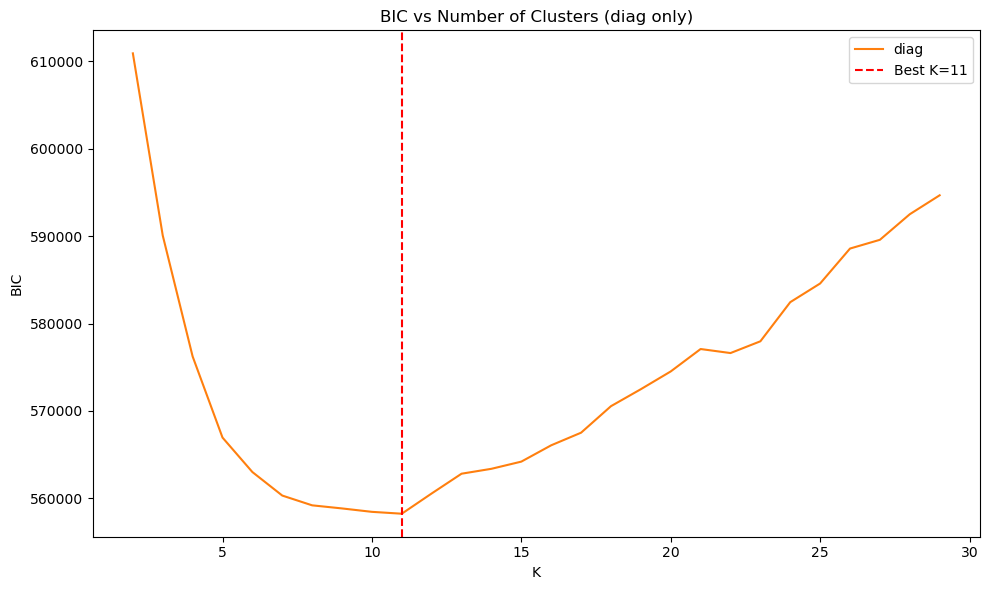

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

# 输入: X_pca (n_segments, n_features)
X_pca = features_pca

# 1. BIC 搜索，仅 diag
K_range = range(2, 30)
best_bic = np.inf
best_gmm = None
bics = []

for K in K_range:
    gmm = GaussianMixture(
        n_components=K,
        covariance_type='full',
        n_init=10,
        random_state=0
    )
    gmm.fit(X_pca)
    bic = gmm.bic(X_pca)
    bics.append(bic)
    
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm

labels = best_gmm.predict(X_pca)
print(f"最优: K={best_gmm.n_components}, cov=diag, BIC={best_bic:.1f}")

# 2. 绘制 BIC 曲线
plt.figure(figsize=(10, 6))
plt.plot(K_range, bics, color='tab:orange', label='diag')
plt.axvline(best_gmm.n_components, color='red', linestyle='--', label=f'Best K={best_gmm.n_components}')
plt.xlabel('K')
plt.ylabel('BIC')
plt.title('BIC vs Number of Clusters (diag only)')
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
gmm = GaussianMixture(
        n_components=3,
        covariance_type='full',
        n_init=10,
        random_state=0)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)

d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


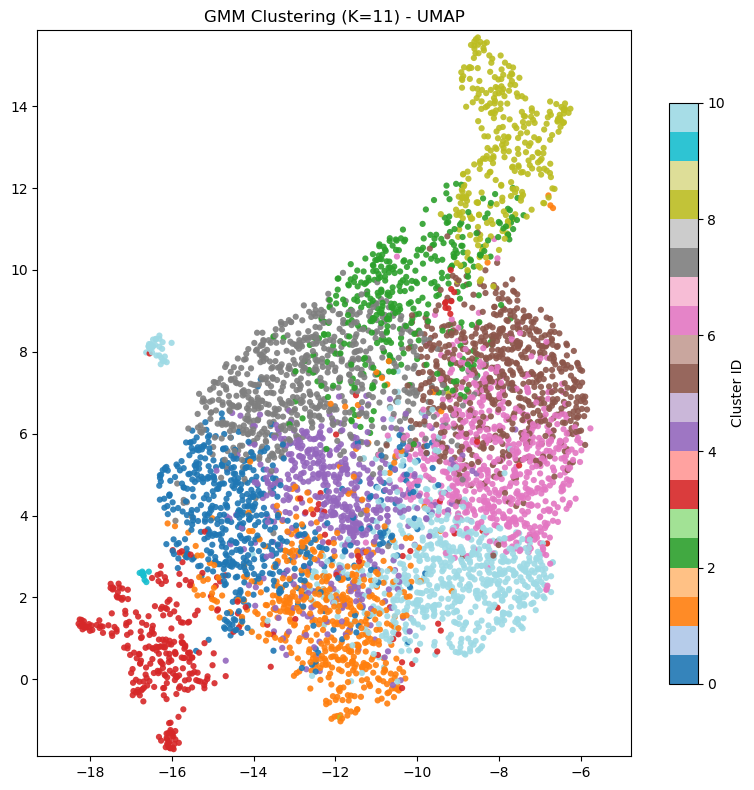

In [52]:
# UMAP 可视化：更小、实心、更紧凑
reducer_umap = umap.UMAP(n_neighbors=10,
                        min_dist=0.5, 
                        random_state=40,
                        spread = 1.0)
X_umap = reducer_umap.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=labels, 
    cmap='tab20'[0:5], 
    s=20,              # 点更小
    marker='o',       # 实心圆
    linewidths=0,     # 无描边
    edgecolors='none',
    alpha=0.9
)

# 收紧坐标轴，消除空白边距，使图像更紧凑
ax.margins(0.01)
ax.set_aspect('equal', adjustable='datalim')

plt.colorbar(scatter, label='Cluster ID', shrink=0.8)
plt.title(f'GMM Clustering (K={best_gmm.n_components}) - UMAP')
plt.tight_layout()
plt.show()

In [53]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def crop_video_and_data(video_path, data_segments, timestamps, labels, duration_sec=120.0):
    """
    按 IMU 时间戳起点对齐，裁剪视频和前 duration_sec 秒的 IMU 数据。
    """
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    t_start = full_times[0]
    t_end_crop = t_start + duration_sec
    
    # 裁剪 IMU 数据
    idx_end = np.searchsorted(full_times, t_end_crop)
    idx_end = min(idx_end, len(full_times))
    
    cropped_segments = []
    cropped_labels = []
    total_samples = 0
    
    for i, seg in enumerate(data_segments):
        seg_len = len(seg)
        if total_samples >= idx_end:
            break
        
        seg_start = total_samples
        if seg_start + seg_len <= idx_end:
            cropped_segments.append(seg)
            cropped_labels.append(labels[i])
        else:
            keep = idx_end - seg_start
            cropped_segments.append(seg[:keep])
            cropped_labels.append(labels[i])
        
        total_samples += seg_len
    
    cropped_times = full_times[:idx_end]
    
    # 裁剪视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    frame_start = max(0, int(np.floor(t_start * fps)))
    frame_end = min(total_frames, int(np.ceil(t_end_crop * fps)) + 1)
    n_frames_crop = frame_end - frame_start
    
    if frame_start > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    name, ext = os.path.splitext(base_name)
    cropped_video_path = os.path.join(dir_name, f"{name}_2min_aligned{ext}")
    
    out = cv2.VideoWriter(cropped_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    
    for _ in tqdm(range(n_frames_crop), desc="Cropping video"):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
    
    out.release()
    cap.release()
    
    print(f"IMU: {t_start:.3f}s ~ {t_end_crop:.3f}s | Video frames: {frame_start}~{frame_end} (n={n_frames_crop})")
    print(f"Saved: {cropped_video_path}")
    
    return cropped_video_path, cropped_segments, cropped_times, np.array(cropped_labels)


def render_cluster_video(video_path, data_segments, timestamps, labels, 
                         window_sec=4.0, step=2, plot_dpi=80):
    """
    合成 IMU 滚动波形 + Cluster 标记视频。
    """
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    # ========== 关键修复：时间戳归一化到 0，与裁剪视频起点对齐 ==========
    time_offset = full_times[0]
    full_times = full_times - time_offset
    
    n_total = len(full_times)
    
    # 计算每段起止时间（归一化后）
    seg_info = []
    idx = 0
    for i, seg in enumerate(data_segments):
        m = len(seg)
        seg_info.append({
            'start_idx': idx,
            'end_idx': idx + m,
            't_start': full_times[idx],
            't_end': full_times[idx + m - 1] if m > 1 else full_times[idx],
            'label': int(labels[i]),
            'seg_id': i
        })
        idx += m
    
    # 打开视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # 归一化后时间从 0 开始，视频帧也从 0 开始
    t_start = 0.0
    t_end = full_times[-1]
    frame_start = 0
    frame_end = total_frames
    
    print(f"Video: {total_frames} frames, fps={fps}, duration={total_frames/fps:.1f}s")
    print(f"IMU: {n_total} samples, normalized time 0 ~ {t_end:.3f}s")
    
    # 输出路径
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    out_path = os.path.join(dir_name, "cluster_overlay_" + base_name)
    
    wave_h = 320
    progress_h = 60
    total_plot_h = wave_h + progress_h
    
    out_fps = fps / step
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h + total_plot_h))
    
    half = window_sec / 2.0
    
    # 预计算每帧对应的 segment
    n_frames = frame_end - frame_start
    frame_times_all = (np.arange(frame_start, frame_end) + 0.5) / fps
    
    seg_starts = np.array([s['t_start'] for s in seg_info])
    seg_ends = np.array([s['t_end'] for s in seg_info])
    seg_labels_arr = np.array([s['label'] for s in seg_info])
    seg_ids_arr = np.array([s['seg_id'] for s in seg_info])
    
    frame_seg_idx = np.searchsorted(seg_starts, frame_times_all, side='right') - 1
    frame_seg_idx = np.clip(frame_seg_idx, 0, len(seg_info) - 1)
    valid_mask = (frame_times_all >= seg_starts[frame_seg_idx]) & (frame_times_all <= seg_ends[frame_seg_idx])
    frame_seg_idx[~valid_mask] = -1
    
    # Cluster 颜色
    unique_labels = sorted(set(seg_labels_arr))
    cmap = plt.cm.get_cmap('tab20', max(len(unique_labels), 20))
    label_colors = {lab: cmap(i) for i, lab in enumerate(unique_labels)}
    
    # 跳帧循环
    process_frames = np.arange(frame_start, frame_end, step)
    print(f"Processing {len(process_frames)} frames (step={step})")
    
    for fi in tqdm(process_frames, desc="Rendering", total=len(process_frames)):
        t = fi / fps  # 归一化时间
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # IMU 窗口
        i0 = np.searchsorted(full_times, t - half)
        i1 = np.searchsorted(full_times, t + half)
        i0 = max(0, i0)
        i1 = min(n_total, i1)
        tw = full_times[i0:i1]
        dw = full_data[i0:i1, :]
        if len(tw) < 2:
            continue
        
        # 查预计算标签
        seg_idx = frame_seg_idx[fi - frame_start]
        if seg_idx >= 0:
            curr_label = int(seg_labels_arr[seg_idx])
            curr_seg_id = int(seg_ids_arr[seg_idx])
        else:
            curr_label = -1
            curr_seg_id = -1
        
        # 绘制
        fig = plt.figure(figsize=(w / 150, total_plot_h / 150), dpi=plot_dpi)
        gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.35], hspace=0.08)
        
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        
        # aG 1-3
        colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for ch in range(3):
            ax1.plot(tw, dw[:, ch + 3], color=colors_aG[ch], lw=1.2)
        ax1.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax1.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax1.set_xlim(t - half, t + half)
        ax1.set_ylabel('aG (g)', fontsize=10)
        ax1.set_xticks([])
        ax1.legend(loc='upper left', fontsize=7)
        
        # 角度 7-9
        colors_ang = ['#d62728', '#9467bd', '#8c564b']
        for ch in range(3):
            ax2.plot(tw, dw[:, ch + 6], color=colors_ang[ch], lw=1.2)
        ax2.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax2.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax2.set_xlim(t - half, t + half)
        ax2.set_ylabel('Angle (°)', fontsize=10)
        ax2.set_xlabel('Time (s)', fontsize=10)
        ax2.legend(loc='upper left', fontsize=7)
        
        # 大标签
        if curr_label >= 0:
            color = label_colors.get(curr_label, 'yellow')
            label_text = f"Seg {curr_seg_id} | Cluster {curr_label}"
            for ax in [ax1, ax2]:
                ax.text(
                    0.98, 0.95, label_text,
                    transform=ax.transAxes,
                    fontsize=14, color='darkred', fontweight='bold',
                    ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.85,
                              edgecolor='darkred', linewidth=2)
                )
        
        # 底部滚动条（归一化时间范围）
        ax3.set_xlim(t_start, t_end)
        ax3.set_ylim(0, 1)
        ax3.axis('off')
        for s in seg_info:
            color = label_colors.get(s['label'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], color=color, alpha=0.5, zorder=1)
        ax3.axvspan(t - half, t + half, color='white', alpha=0.25, zorder=2)
        ax3.axvline(t, color='red', lw=2, zorder=5)
        ax3.set_xticks(np.linspace(t_start, t_end, 5))
        ax3.set_xticklabels([f'{x:.1f}s' for x in np.linspace(t_start, t_end, 5)], fontsize=8)
        
        fig.tight_layout()
        fig.canvas.draw()
        
        buf = fig.canvas.buffer_rgba()
        plot_img = np.frombuffer(buf, dtype=np.uint8)
        plot_img = plot_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plot_img = plot_img[:, :, :3]
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)
        
        if plot_img.shape[1] != w or plot_img.shape[0] != total_plot_h:
            plot_img = cv2.resize(plot_img, (w, total_plot_h))
        
        combined = np.vstack([frame, plot_img])
        out.write(combined)
    
    out.release()
    cap.release()
    print(f"Saved: {out_path}")
    return out_path


# ========== 使用示例 ==========
# cropped_video, cropped_segments, cropped_times, cropped_labels = crop_video_and_data(
#     video_path="F:/IMU_computational_ethology/data2.mp4",
#     data_segments=cpd_segments,
#     timestamps=all_timestamps,
#     labels=gmm_labels,
#     duration_sec=120.0
# )

# render_cluster_video(
#     video_path=cropped_video,
#     data_segments=cropped_segments,
#     timestamps=cropped_times,
#     labels=cropped_labels,
#     window_sec=4.0,
#     step=2,
#     plot_dpi=80
# )
#========== 使用示例 ==========
#第一步：裁剪前 2 分钟



In [54]:
cropped_video, cropped_segments, cropped_times, cropped_labels = crop_video_and_data(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2.mp4",
    data_segments=data1_CPDsegments,      # list of (m, 12) arrays
    timestamps=t1_CPDsegments,  
    labels=labels,
    duration_sec=120
)

Cropping video: 100%|██████████| 3598/3598 [02:51<00:00, 20.97it/s]

IMU: 60.007s ~ 180.007s | Video frames: 1798~5396 (n=3598)
Saved: F:/IMU_computational_ethology/Data/LSD\LSD_data2_2min_aligned.mp4


In [55]:
#第二步：合成（跳帧加速）
render_cluster_video(
    video_path=cropped_video,
    data_segments= cropped_segments,      # list of (m, 12) arrays
    timestamps=cropped_times,  
    labels=cropped_labels,
    window_sec=4.0,
    step=1,
    plot_dpi=80
)

C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\826838824.py:156: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(unique_labels), 20))


Video: 3598 frames, fps=29.97, duration=120.1s
IMU: 11915 samples, normalized time 0 ~ 119.994s
Processing 3598 frames (step=1)


Rendering:   0%|          | 0/3598 [00:00<?, ?it/s]C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\826838824.py:209: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=7)
C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\826838824.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=7)
C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\826838824.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
Rendering:   0%|          | 1/3598 [00:00<44:38,  1.34it/s]C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\826838824.py:209: UserWarning: No artists with labels found to put in le

KeyboardInterrupt: 

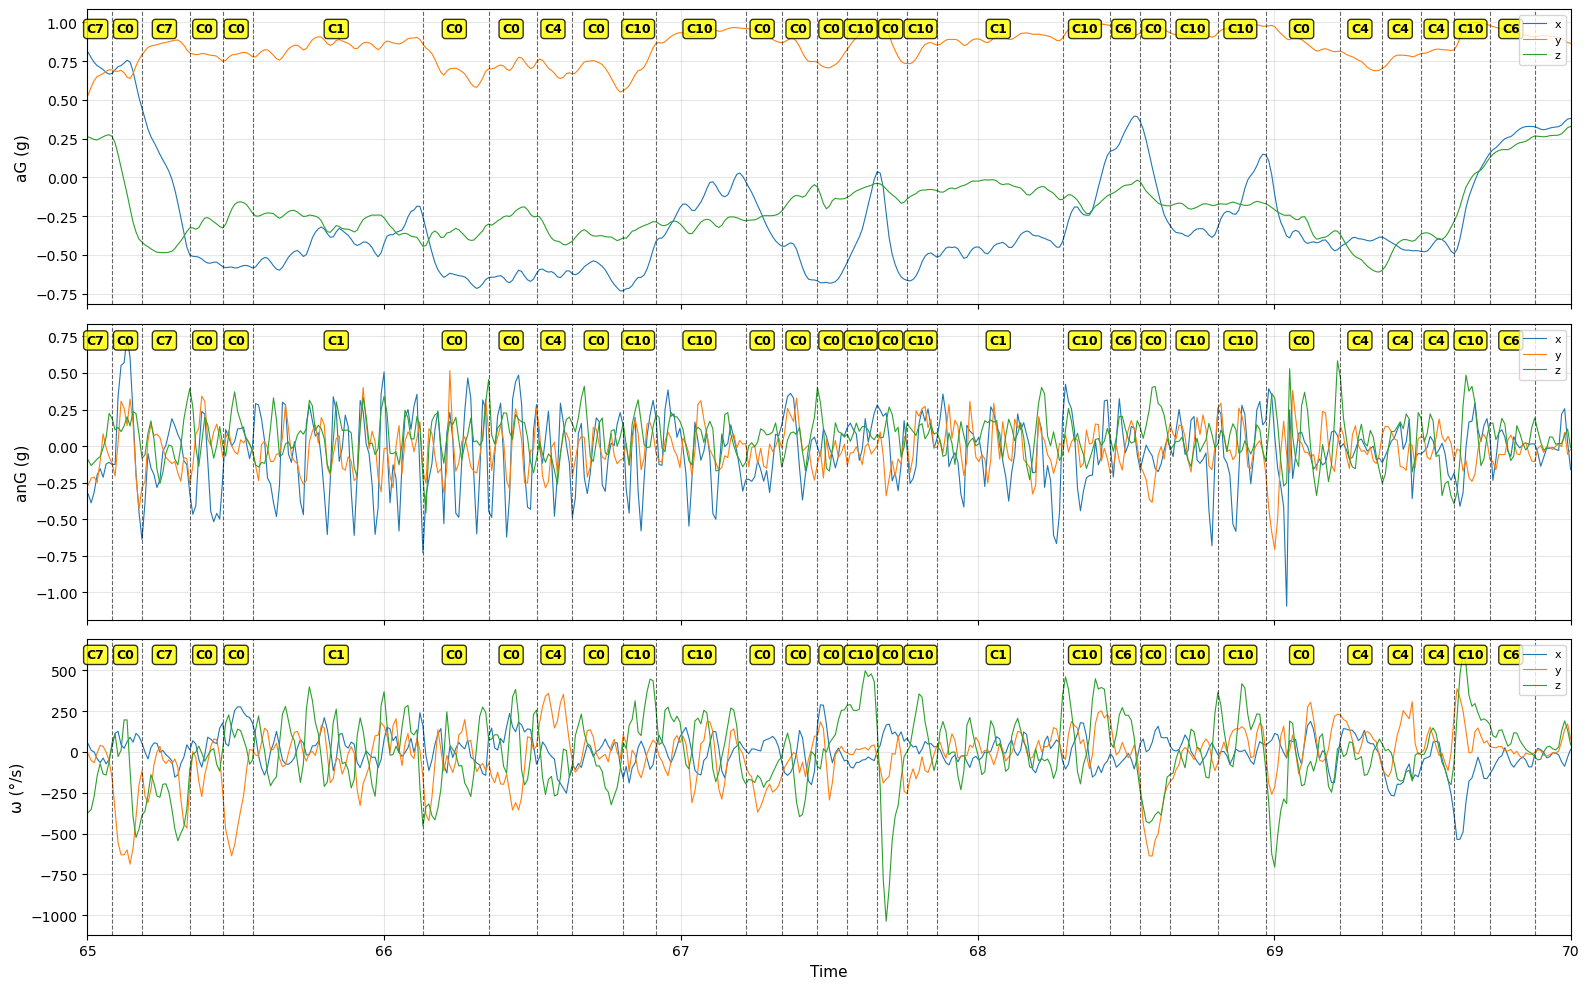

In [50]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def plot_segments_with_labels(data_segments, timestamps, labels, 
                               t_start=None, t_end=None, 
                               figsize=(16, 10)):
    """
    绘制分段 IMU 数据，按时间戳截断，虚线分隔片段，并标注类别。
    
    参数
    ----
    data_segments : list of np.ndarray
        每段 (m, 12)，列顺序: [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]
    timestamps : np.ndarray
        连续时间戳，长度等于所有段样本数之和
    labels : np.ndarray or list
        每段对应的类标签
    t_start, t_end : float or None
        绘制的时间范围（单位与 timestamps 一致）。None 表示全部绘制。
    figsize : tuple
        图像尺寸
    """
    # 1. 拼接完整数据
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    # 2. 时间截断
    if t_start is None:
        t_start = full_times[0]
    if t_end is None:
        t_end = full_times[-1]
    
    idx0 = np.searchsorted(full_times, t_start)
    idx1 = np.searchsorted(full_times, t_end)
    idx0 = max(0, idx0)
    idx1 = min(len(full_times), idx1)
    
    times = full_times[idx0:idx1]
    data = full_data[idx0:idx1, :]
    
    # 3. 计算每段在全局时间中的起止（只保留与视图有交集的）
    seg_starts = []
    seg_ends = []
    seg_labels_view = []
    
    cumsum = 0
    for i, seg in enumerate(data_segments):
        seg_len = len(seg)
        seg_t0 = full_times[cumsum]
        seg_t1 = full_times[cumsum + seg_len - 1] if seg_len > 1 else full_times[cumsum]
        
        if seg_t1 >= t_start and seg_t0 <= t_end:
            seg_starts.append(seg_t0)
            seg_ends.append(seg_t1)
            seg_labels_view.append(int(labels[i]))
        
        cumsum += seg_len
    
    # 4. 绘图
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    
    groups = [
        (data[:, 0:3], 'aG (g)', ['x', 'y', 'z']),
        (data[:, 3:6], 'anG (g)', ['x', 'y', 'z']),
        (data[:, 6:9], 'ω (°/s)', ['x', 'y', 'z'])
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for ax, (d, title, ch_names) in zip(axes, groups):
        # 画三通道曲线
        for ch in range(3):
            ax.plot(times, d[:, ch], color=colors[ch], lw=0.8, label=ch_names[ch])
        
        # 画虚线边界
        for t_b in seg_starts:
            if t_start <= t_b <= t_end:
                ax.axvline(t_b, color='black', linestyle='--', lw=0.8, alpha=0.6)
        
        # 标注类别：在片段中点上方，黄底黑字
        y_top = ax.get_ylim()[1]
        for t0, t1, lab in zip(seg_starts, seg_ends, seg_labels_view):
            mid = (t0 + t1) / 2
            if t_start <= mid <= t_end:
                ax.text(mid, y_top * 0.92, f'C{lab}', 
                        ha='center', va='top', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='yellow', alpha=0.8))
        
        ax.set_ylabel(title, fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(t_start, t_end)
    
    axes[-1].set_xlabel('Time', fontsize=11)
    plt.tight_layout()
    plt.show()


# ========== 使用示例 ==========
plot_segments_with_labels(
    data_segments= data1_CPDsegments,      # list of (m, 12)
    timestamps=t1_CPDsegments,         # (n_total,)
    labels=labels,                 # (n_segments,)
    t_start=65,                       # 从第 0 秒开始
    t_end=70,                        # 画前 30 秒
    figsize=(16, 10)
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

def fit_categorical_hmm_bic(labels, K, S_max=15, n_restarts=10):
    """
    按照原文方法拟合分类 HMM，通过 BIC 选择最优隐藏状态数 S。
    
    参数
    ----
    labels : np.ndarray, shape (N,)
        观测序列，每个元素为 0..K-1 的整数（cluster 标签）
    K : int
        观测类别数（clusters 数）
    S_max : int
        隐藏状态数搜索上限（原文 1–30）
    n_restarts : int
        每个 S 的随机初始化次数（原文 10 次）
        
    返回
    ----
    best_model : hmm.CategoricalHMM
    best_S : int
    best_bic : float
    state_sequence : np.ndarray, shape (N,)
        Viterbi 解码后的最优隐藏状态序列
    """
    # 确保输入格式
    Y = np.asarray(labels).flatten()
    if Y.min() < 0 or Y.max() >= K:
        raise ValueError("labels must be integers in range [0, K-1]")
    X = Y.reshape(-1, 1)
    N = len(Y)
    
    best_bic = -np.inf
    best_model = None
    best_S = None
    
    print("Searching optimal S via BIC...")
    for S in range(1, S_max + 1):
        bic_scores = []
        models = []
        
        for r in range(n_restarts):
            # 原文：100 次 EM 迭代，随机初始化
            model = hmm.CategoricalHMM(
                n_components=S,
                n_features=K,
                n_iter=100,
                random_state=None,
                init_params='ste'
            )
            try:
                model.fit(X)
                log_likelihood = model.score(X)
                
                # 参数数量 m_S（原文公式）
                # startprob: S-1, transmat: S*(S-1), emissionprob: S*(K-1)
                m_S = (S - 1) + S * (S - 1) + S * (K - 1)
                
                # BIC = 2*logL - m_S*log(N)
                bic = 2 * log_likelihood - m_S * np.log(N)
                bic_scores.append(bic)
                models.append(model)
            except Exception:
                bic_scores.append(-np.inf)
                models.append(None)
        
        idx_best = int(np.argmax(bic_scores))
        bic_best_S = bic_scores[idx_best]
        print(f"  S={S:2d}: best BIC={bic_best_S:.1f}")
        
        if bic_best_S > best_bic:
            best_bic = bic_best_S
            best_model = models[idx_best]
            best_S = S
    
    # Viterbi 解码（原文 E-step）
    state_sequence = best_model.predict(X)
    
    print(f"\nOptimal: S={best_S}, BIC={best_bic:.1f}")
    return best_model, best_S, best_bic, state_sequence


def visualize_hmm(model, labels, K, best_S, state_sequence, figsize=(14, 10)):
    """
    HMM 结果可视化，贴近原文 Fig 6 风格。
    """
    Y = np.asarray(labels).flatten()
    N = len(Y)
    
    E = model.emissionprob_          # (S, K)
    A = model.transmat_              # (S, S)
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.35, wspace=0.3)
    
    # ---------- 子图 1: 发射概率矩阵 (类似 Fig 6A) ----------
    ax1 = fig.add_subplot(gs[0, :])
    im1 = ax1.imshow(E, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_xlabel('Cluster ID', fontsize=11)
    ax1.set_ylabel('Hidden State', fontsize=11)
    ax1.set_title('Emission Probabilities  P(cluster | state)', fontsize=12, fontweight='bold')
    ax1.set_xticks(np.arange(K))
    ax1.set_yticks(np.arange(best_S))
    plt.colorbar(im1, ax=ax1, label='Probability')
    
    for i in range(best_S):
        for j in range(K):
            if E[i, j] > 0.15:
                ax1.text(j, i, f'{E[i,j]:.2f}', ha='center', va='center', 
                        color='white' if E[i,j] > 0.6 else 'black', fontsize=7)
    
    # ---------- 子图 2: 转移矩阵 (类似 Fig 6B) ----------
    ax2 = fig.add_subplot(gs[1, 0])
    im2 = ax2.imshow(A, aspect='auto', cmap='Greys', vmin=0, vmax=1)
    ax2.set_xlabel('To State', fontsize=11)
    ax2.set_ylabel('From State', fontsize=11)
    ax2.set_title('State Transition Matrix', fontsize=12, fontweight='bold')
    ax2.set_xticks(np.arange(best_S))
    ax2.set_yticks(np.arange(best_S))
    plt.colorbar(im2, ax=ax2, label='Probability')
    
    # ---------- 子图 3: 每个状态的主导 Cluster ----------
    ax3 = fig.add_subplot(gs[1, 1])
    dominant_clusters = np.argmax(E, axis=1)
    dominant_probs = np.max(E, axis=1)
    
    y_pos = np.arange(best_S)
    ax3.barh(y_pos, dominant_probs, color='steelblue', edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f'State {i}' for i in range(best_S)])
    ax3.set_xlabel('Max Emission Probability', fontsize=11)
    ax3.set_title('Dominant Cluster per State', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    
    for i, (prob, clus) in enumerate(zip(dominant_probs, dominant_clusters)):
        ax3.text(prob + 0.02, i, f'C{clus}', va='center', fontsize=9, fontweight='bold')
    
    # ---------- 子图 4: 状态序列与观测序列 (类似 Fig 6D) ----------
    ax4 = fig.add_subplot(gs[2, :])
    
    show_n = min(N, 800)
    t = np.arange(show_n)
    
    ax4.scatter(t, Y[:show_n], c='lightgray', s=12, alpha=0.5, label='Cluster (GMM)', zorder=1)
    ax4.step(t, state_sequence[:show_n], where='mid', color='darkred', lw=2, label='Hidden State (HMM)', zorder=2)
    
    ax4.set_xlabel('Segment Index', fontsize=11)
    ax4.set_ylabel('State / Cluster ID', fontsize=11)
    ax4.set_title('State Sequence (Viterbi Decoding)', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.set_ylim(-0.5, max(best_S, K) - 0.5)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.show()
    
    # 打印映射表
    print("\n--- State-Cluster Mapping ---")
    for i in range(best_S):
        top3 = np.argsort(E[i])[::-1][:3]
        probs = E[i, top3]
        print(f"State {i:2d}: top clusters = {top3} (probs: {probs.round(3)})")


# ========== 使用示例 ==========
# 确保 labels 是 0-based 整数
if labels.min() != 0:
    labels = labels - labels.min()

best_model, best_S, best_bic, state_seq = fit_categorical_hmm_bic(
    labels=labels, 
    K=11, 
    S_max=15, 
    n_restarts=10
)


Searching optimal S via BIC...
  S= 1: best BIC=-23653.0
  S= 2: best BIC=-20469.4
  S= 3: best BIC=-19253.3


KeyboardInterrupt: 

C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\1964631396.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


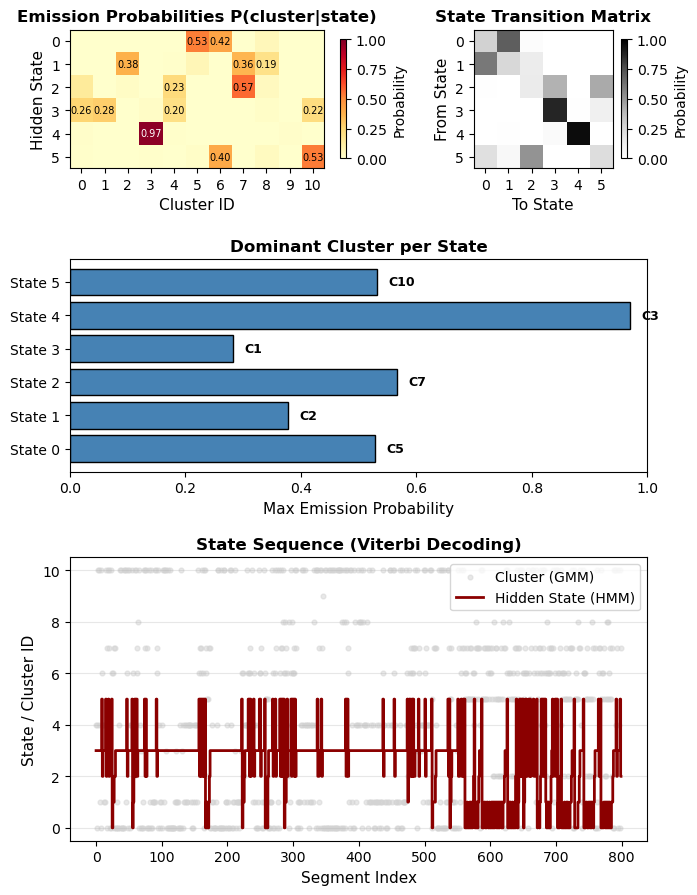


--- State-Cluster Mapping ---
State  0: top clusters = [5 6 8] (probs: [0.529 0.415 0.053])
State  1: top clusters = [2 7 8] (probs: [0.378 0.36  0.194])
State  2: top clusters = [7 4 0] (probs: [0.567 0.232 0.14 ])
State  3: top clusters = [ 1  0 10] (probs: [0.282 0.258 0.219])
State  4: top clusters = [3 0 9] (probs: [0.971 0.011 0.008])
State  5: top clusters = [10  6  8] (probs: [0.533 0.404 0.032])


In [65]:
%matplotlib inline

def visualize_hmm(model, labels, K, best_S, state_sequence, cell_size=0.35):
    """
    HMM 结果可视化，保持矩阵原始比例（方形单元格），不纵向压缩。
    布局：发射矩阵与转移矩阵并排（各自单元格为正方形），
          主导图与序列图在下侧展开。
    """
    Y = np.asarray(labels).flatten()
    N = len(Y)
    E = model.emissionprob_
    A = model.transmat_
    
    # 动态 figsize：根据数据维度计算，确保单元格接近正方形
    # 发射矩阵 E: 宽 K, 高 S  |  转移矩阵 A: 宽 S, 高 S
    w0 = K * cell_size
    w1 = best_S * cell_size
    h0 = best_S * cell_size
    h1 = max(best_S * cell_size * 0.4, 3)
    h2 = 4
    
    fig = plt.figure(figsize=(w0 + w1 + 1.5, h0 + h1 + h2 + 1.5))
    gs = fig.add_gridspec(3, 2, 
                          width_ratios=[w0, w1], 
                          height_ratios=[h0, h1, h2],
                          hspace=0.4, wspace=0.35)
    
    # ---------- 子图 1: 发射概率矩阵 (S, K) ----------
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(E, aspect='equal', cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_xlabel('Cluster ID', fontsize=11)
    ax1.set_ylabel('Hidden State', fontsize=11)
    ax1.set_title('Emission Probabilities P(cluster|state)', fontsize=12, fontweight='bold')
    ax1.set_xticks(np.arange(K))
    ax1.set_yticks(np.arange(best_S))
    plt.colorbar(im1, ax=ax1, label='Probability', shrink=0.8)
    
    for i in range(best_S):
        for j in range(K):
            if E[i, j] > 0.15:
                ax1.text(j, i, f'{E[i,j]:.2f}', ha='center', va='center', 
                        color='white' if E[i,j] > 0.6 else 'black', fontsize=7)
    
    # ---------- 子图 2: 转移矩阵 (S, S) 方形 ----------
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(A, aspect='equal', cmap='Greys', vmin=0, vmax=1)
    ax2.set_xlabel('To State', fontsize=11)
    ax2.set_ylabel('From State', fontsize=11)
    ax2.set_title('State Transition Matrix', fontsize=12, fontweight='bold')
    ax2.set_xticks(np.arange(best_S))
    ax2.set_yticks(np.arange(best_S))
    plt.colorbar(im2, ax=ax2, label='Probability', shrink=0.8)
    
    # ---------- 子图 3: 主导 Cluster（跨两列） ----------
    ax3 = fig.add_subplot(gs[1, :])
    dominant_clusters = np.argmax(E, axis=1)
    dominant_probs = np.max(E, axis=1)
    y_pos = np.arange(best_S)
    ax3.barh(y_pos, dominant_probs, color='steelblue', edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f'State {i}' for i in range(best_S)])
    ax3.set_xlabel('Max Emission Probability', fontsize=11)
    ax3.set_title('Dominant Cluster per State', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    for i, (prob, clus) in enumerate(zip(dominant_probs, dominant_clusters)):
        ax3.text(prob + 0.02, i, f'C{clus}', va='center', fontsize=9, fontweight='bold')
    
    # ---------- 子图 4: 状态序列（跨两列） ----------
    ax4 = fig.add_subplot(gs[2, :])
    show_n = min(N, 800)
    t = np.arange(show_n)
    ax4.scatter(t, Y[:show_n], c='lightgray', s=12, alpha=0.5, label='Cluster (GMM)', zorder=1)
    ax4.step(t, state_sequence[:show_n], where='mid', color='darkred', lw=2, label='Hidden State (HMM)', zorder=2)
    ax4.set_xlabel('Segment Index', fontsize=11)
    ax4.set_ylabel('State / Cluster ID', fontsize=11)
    ax4.set_title('State Sequence (Viterbi Decoding)', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.set_ylim(-0.5, max(best_S, K) - 0.5)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # 打印映射表
    print("\n--- State-Cluster Mapping ---")
    for i in range(best_S):
        top3 = np.argsort(E[i])[::-1][:3]
        probs = E[i, top3]
        print(f"State {i:2d}: top clusters = {top3} (probs: {probs.round(3)})")


# ========== 使用示例 ==========
# best_model, best_S, best_bic, state_seq = fit_categorical_hmm_bic(
#     labels=labels, K=11, S_max=15, n_restarts=10
# )
# visualize_hmm(best_model, labels, 11, best_S, state_seq, cell_size=0.35)
visualize_hmm(best_model, labels, 11, best_S, state_seq)

In [68]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def crop_video_and_data(video_path, data_segments, timestamps, duration_sec=120.0):
    """
    按 IMU 时间戳起点对齐，裁剪视频和前 duration_sec 秒的 IMU 数据。
    """
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    t_start = full_times[0]
    t_end_crop = t_start + duration_sec
    
    idx_end = np.searchsorted(full_times, t_end_crop)
    idx_end = min(idx_end, len(full_times))
    
    cropped_segments = []
    total_samples = 0
    for seg in data_segments:
        seg_len = len(seg)
        if total_samples >= idx_end:
            break
        if total_samples + seg_len <= idx_end:
            cropped_segments.append(seg)
        else:
            cropped_segments.append(seg[:idx_end - total_samples])
        total_samples += seg_len
    
    cropped_times = full_times[:idx_end]
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    frame_start = max(0, int(np.floor(t_start * fps)))
    frame_end = min(total_frames, int(np.ceil(t_end_crop * fps)) + 1)
    n_frames_crop = frame_end - frame_start
    
    if frame_start > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    name, ext = os.path.splitext(base_name)
    cropped_video_path = os.path.join(dir_name, f"{name}_2min_aligned{ext}")
    
    out = cv2.VideoWriter(cropped_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for _ in tqdm(range(n_frames_crop), desc="Cropping video"):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
    
    out.release()
    cap.release()
    print(f"Saved: {cropped_video_path}")
    return cropped_video_path, cropped_segments, cropped_times


def render_hmm_states_video(video_path, data_segments, timestamps, state_sequence,
                            window_sec=4.0, step=2, plot_dpi=80):
    """
    将 HMM 隐藏状态合成到视频上。
    输入 state_sequence 为每段对应的 HMM 状态标签，长度等于 data_segments 数量。
    """
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    full_times = full_times - full_times[0]  # 归一化到 0
    n_total = len(full_times)
    
    S = int(np.max(state_sequence)) + 1  # 状态数
    
    # 计算每段起止时间
    seg_info = []
    idx = 0
    for i, seg in enumerate(data_segments):
        m = len(seg)
        seg_info.append({
            'start_idx': idx,
            'end_idx': idx + m,
            't_start': full_times[idx],
            't_end': full_times[idx + m - 1] if m > 1 else full_times[idx],
            'state': int(state_sequence[i]),
            'seg_id': i
        })
        idx += m
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    t_start = 0.0
    t_end = full_times[-1]
    frame_start = 0
    frame_end = total_frames
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    out_path = os.path.join(dir_name, "hmm_states_" + base_name)
    
    wave_h = 320
    progress_h = 60
    total_plot_h = wave_h + progress_h
    
    out_fps = fps / step
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h + total_plot_h))
    
    half = window_sec / 2.0
    
    # 预计算每帧对应的 HMM 状态
    n_frames = frame_end - frame_start
    frame_times_all = (np.arange(frame_start, frame_end) + 0.5) / fps
    
    seg_starts = np.array([s['t_start'] for s in seg_info])
    seg_ends = np.array([s['t_end'] for s in seg_info])
    seg_states_arr = np.array([s['state'] for s in seg_info])
    seg_ids_arr = np.array([s['seg_id'] for s in seg_info])
    
    frame_seg_idx = np.searchsorted(seg_starts, frame_times_all, side='right') - 1
    frame_seg_idx = np.clip(frame_seg_idx, 0, len(seg_info) - 1)
    valid_mask = (frame_times_all >= seg_starts[frame_seg_idx]) & (frame_times_all <= seg_ends[frame_seg_idx])
    frame_seg_idx[~valid_mask] = -1
    
    # HMM 状态颜色
    cmap = plt.cm.get_cmap('tab20', max(S, 20))
    state_colors = {s: cmap(i) for i, s in enumerate(sorted(set(seg_states_arr)))}
    
    process_frames = np.arange(frame_start, frame_end, step)
    
    for fi in tqdm(process_frames, desc="Rendering HMM states", total=len(process_frames)):
        t = fi / fps
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # IMU 窗口
        i0 = np.searchsorted(full_times, t - half)
        i1 = np.searchsorted(full_times, t + half)
        i0 = max(0, i0)
        i1 = min(n_total, i1)
        tw = full_times[i0:i1]
        dw = full_data[i0:i1, :]
        if len(tw) < 2:
            continue
        
        # 查 HMM 状态
        seg_idx = frame_seg_idx[fi - frame_start]
        if seg_idx >= 0:
            curr_state = int(seg_states_arr[seg_idx])
            curr_seg_id = int(seg_ids_arr[seg_idx])
        else:
            curr_state = -1
            curr_seg_id = -1
        
        # 绘制
        fig = plt.figure(figsize=(w / 150, total_plot_h / 150), dpi=plot_dpi)
        gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.35], hspace=0.08)
        
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        
        # aG 1-3
        colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for ch in range(3):
            ax1.plot(tw, dw[:, ch], color=colors_aG[ch], lw=1.2)
        ax1.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax1.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax1.set_xlim(t - half, t + half)
        ax1.set_ylabel('aG (g)', fontsize=10)
        ax1.set_xticks([])
        ax1.legend(loc='upper left', fontsize=7)
        
        # 角度 7-9
        colors_ang = ['#d62728', '#9467bd', '#8c564b']
        for ch in range(3):
            ax2.plot(tw, dw[:, ch + 9], color=colors_ang[ch], lw=1.2)
        ax2.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax2.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax2.set_xlim(t - half, t + half)
        ax2.set_ylabel('Angle (°)', fontsize=10)
        ax2.set_xlabel('Time (s)', fontsize=10)
        ax2.legend(loc='upper left', fontsize=7)
        
        # HMM 状态大标签
        if curr_state >= 0:
            color = state_colors.get(curr_state, 'yellow')
            label_text = f"Seg {curr_seg_id} | State {curr_state}"
            for ax in [ax1, ax2]:
                ax.text(
                    0.98, 0.95, label_text,
                    transform=ax.transAxes,
                    fontsize=14, color='darkred', fontweight='bold',
                    ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.85,
                              edgecolor='darkred', linewidth=2)
                )
        
        # 底部滚动条：按 HMM 状态着色
        ax3.set_xlim(t_start, t_end)
        ax3.set_ylim(0, 1)
        ax3.axis('off')
        for s in seg_info:
            color = state_colors.get(s['state'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], color=color, alpha=0.5, zorder=1)
        ax3.axvspan(t - half, t + half, color='white', alpha=0.25, zorder=2)
        ax3.axvline(t, color='red', lw=2, zorder=5)
        ax3.set_xticks(np.linspace(t_start, t_end, 5))
        ax3.set_xticklabels([f'{x:.1f}s' for x in np.linspace(t_start, t_end, 5)], fontsize=8)
        
        fig.tight_layout()
        fig.canvas.draw()
        
        buf = fig.canvas.buffer_rgba()
        plot_img = np.frombuffer(buf, dtype=np.uint8)
        plot_img = plot_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plot_img = plot_img[:, :, :3]
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)
        
        if plot_img.shape[1] != w or plot_img.shape[0] != total_plot_h:
            plot_img = cv2.resize(plot_img, (w, total_plot_h))
        
        combined = np.vstack([frame, plot_img])
        out.write(combined)
    
    out.release()
    cap.release()
    print(f"Saved: {out_path}")
    return out_path


# ========== 使用示例 ==========
# 1. 裁剪前 2 分钟
# cropped_video, cropped_segments, cropped_times = crop_video_and_data(
#     video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2.mp4",
#     data_segments=cpd_segments,
#     timestamps=all_timestamps,
#     duration_sec=120.0
# )




In [69]:

#3. 合成 HMM 状态视频
render_hmm_states_video(
    video_path=cropped_video,
    data_segments=cropped_segments,
    timestamps=cropped_times,
    state_sequence=state_seq,
    window_sec=4.0,
    step=3,
    plot_dpi=80
)

C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\1588823155.py:134: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(S, 20))
Rendering HMM states:   0%|          | 0/1200 [00:00<?, ?it/s]

C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\1588823155.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=7)
C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\1588823155.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=7)
C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\1588823155.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
Rendering HMM states:   0%|          | 1/1200 [00:00<10:57,  1.82it/s]C:\Users\Shubai\AppData\Local\Temp\ipykernel_27204\1588823155.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label

Saved: F:/IMU_computational_ethology/Data/LSD\hmm_states_LSD_data2_2min_aligned.mp4


'F:/IMU_computational_ethology/Data/LSD\\hmm_states_LSD_data2_2min_aligned.mp4'